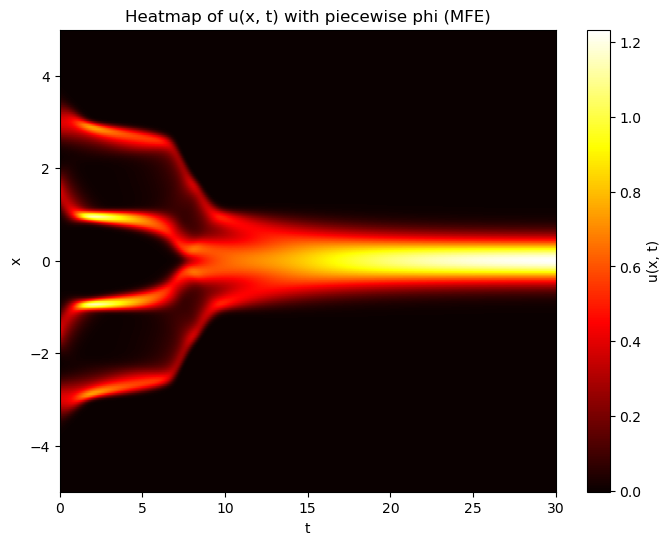

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.signal import convolve
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# SDE particle system simulation parameters
x_min, x_max = -5, 5
t_min, t_max = 0, 30
dx = 0.05
dt = 0.001
nu = 0.01

nx = int((x_max - x_min) / dx) + 1
nt = int((t_max - t_min) / dt) + 1

x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)

u = np.zeros((nt, nx))

u[0, :] = (1/4)*(norm.pdf(x, -3, 0.25) + norm.pdf(x, 1.5, 0.25) + norm.pdf(x, -1.5, 0.25) + norm.pdf(x, 3, 0.25))

def f_true(r):
    res = np.zeros_like(r)
    mask1 = (r >= 0) & (r <= 2)      
    mask2 = (r > 2) & (r <= 3)      
    mask3 = (r > 3)                  
    res[mask1] = 0.1                 
    res[mask2] = 1                  
    res[mask3] = 0               
    return res

def phi_true_func(r):
    return f_true(r) * r

def K_phi_true(x):
    abs_x = np.abs(x)
    sign_x = np.sign(x)
    return phi_true_func(abs_x) * sign_x

def convolve_K_phi_u(u_vector, x):
    K_phi_values = K_phi_true(x)
    return convolve(u_vector, K_phi_values, mode='same') * dx

def compute_rhs(u_vector, x):
    uxx = (np.roll(u_vector, -1) - 2*u_vector + np.roll(u_vector, 1)) / dx**2
    nu_uxx = nu * uxx
    conv_term = convolve_K_phi_u(u_vector, x)
    uxKphi = (np.roll(u_vector * conv_term, -1) - np.roll(u_vector * conv_term, 1)) / (2 * dx)
    return nu_uxx + uxKphi

for n in range(nt-1):
    k1 = dt * compute_rhs(u[n, :], x)
    k2 = dt * compute_rhs(u[n, :] + 0.5*k1, x)
    k3 = dt * compute_rhs(u[n, :] + 0.5*k2, x)
    k4 = dt * compute_rhs(u[n, :] + k3, x)
    u[n+1, :] = u[n, :] + (k1 + 2*k2 + 2*k3 + k4) / 6

plt.figure(figsize=(8, 6))
plt.imshow(u.T, extent=[t_min, t_max, x_min, x_max],
           aspect='auto', cmap='hot', origin='lower')
plt.colorbar(label='u(x, t)')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Heatmap of u(x, t) with piecewise phi (MFE)')
plt.show()




迭代 1
优化后的 xi: [ 9.99994731e-02  4.59782385e-06  1.00064747e+00 -1.90917864e-04
  9.79808281e-05 -2.91474246e-05]
当前阈值: 0.050032373478943674
需要稀疏的系数索引: [1 3 4 5]
当前损失值（带稀疏性约束）: 1.192697

迭代 2
优化后的 xi: [0.09998888 0.         1.00018462 0.         0.         0.        ]
当前阈值: 0.05000923075817289
需要稀疏的系数索引: []
当前损失值（带稀疏性约束）: 1.174722

迭代 3
优化后的 xi: [0.09995086 0.         1.00016349 0.         0.         0.        ]
当前阈值: 0.05000817428376036
需要稀疏的系数索引: []
当前损失值（带稀疏性约束）: 1.180143

迭代 4
优化后的 xi: [0.09999788 0.         1.00013649 0.         0.         0.        ]
当前阈值: 0.05000682438119217
需要稀疏的系数索引: []
当前损失值（带稀疏性约束）: 1.180406

迭代 5
优化后的 xi: [0.09997406 0.         1.00018346 0.         0.         0.        ]
当前阈值: 0.05000917314124334
需要稀疏的系数索引: []
当前损失值（带稀疏性约束）: 1.180206

迭代 6
优化后的 xi: [0.10000321 0.         1.00018301 0.         0.         0.        ]
当前阈值: 0.05000915065165225
需要稀疏的系数索引: []
当前损失值（带稀疏性约束）: 1.180169

迭代 7
优化后的 xi: [0.09994572 0.         1.00022124 0.         0.         0.      

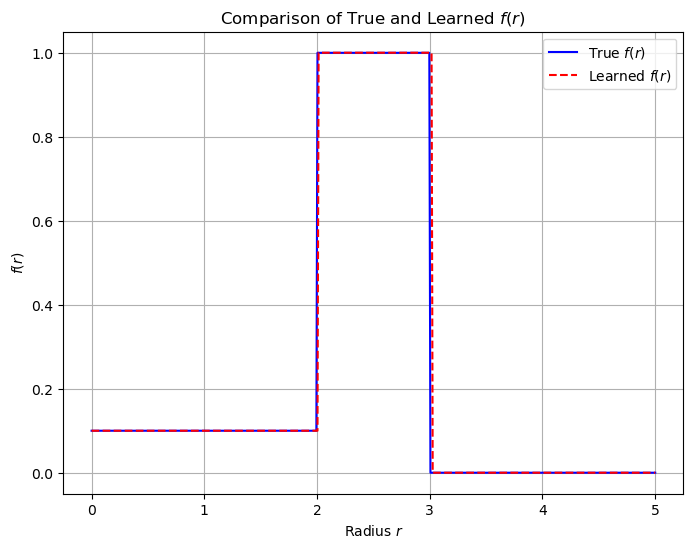

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.signal import fftconvolve
import warnings

warnings.filterwarnings("ignore")  



def base_library(r, degree=1):   

    terms = [r**i for i in range(degree+1)]
    return np.vstack(terms)

def piecewise_library(r, break_points, degree=1):

    r = np.asarray(r)
    r1, r2 = break_points
    region1_mask = (r <= r1)
    region2_mask = (r > r1) & (r <= r2)
    region3_mask = (r > r2)

    lib = base_library(r, degree=degree)  # (degree+1, len(r))

    lib_region1 = lib * region1_mask  # [1, r] * mask for region1
    lib_region2 = lib * region2_mask  # [1, r] * mask for region2
    lib_region3 = lib * region3_mask  # [1, r] * mask for region3

    piecewise_lib = np.concatenate([lib_region1, lib_region2, lib_region3], axis=0)  # 3*(degree+1) x len(r)

    return piecewise_lib.T  # Shape: (len(r), 6)


# Discontinuity points identified from the DNN part
break_points = [2.01, 3.02]

def generate_candidate_library_f(x, break_points):

    abs_x = np.abs(x)
    Theta_f = piecewise_library(abs_x, break_points, degree=1)  
    return Theta_f  # Shape: (nx, 6)

# K_f(x) = f(|x|) * x
def calculate_K_f(x, xi, break_points):
    abs_x = np.abs(x)
    Theta_f = piecewise_library(abs_x, break_points, degree=1)
    # f(r) = Theta_f * xi
    f_r = Theta_f @ xi
    # K_f(x) = f(|x|) * x
    K_f = f_r * x
    return K_f

def compute_rhs_f(u_vector, x, xi, break_points, dx, nu):

    K_f = calculate_K_f(x, xi, break_points)
    conv_term = fftconvolve(u_vector, K_f, mode='same') * dx
    u_conv = u_vector * conv_term
    gradient_u_conv = (np.roll(u_conv, -1) - np.roll(u_conv, 1)) / (2 * dx)
    uxx = (np.roll(u_vector, -1) - 2 * u_vector + np.roll(u_vector, 1)) / dx**2
    nu_uxx = nu * uxx
    return nu_uxx + gradient_u_conv

def calculate_error_f(n, u, dt, dx, x, xi, break_points, nu):

    if n == 0:
        return 0  
    u_t = (u[n, :] - u[n - 1, :]) / dt

    rhs = compute_rhs_f(u[n, :], x, xi, break_points, dx, nu)

    error = u_t - rhs
    return np.sum(error ** 2)


def calculate_total_error_f(xi, u, dt, dx, x, break_points, nu):

    errors = np.array([
        calculate_error_f(n, u, dt, dx, x, xi, break_points, nu)
        for n in range(1, u.shape[0])
    ])
    return errors  # Shape: (nt-1,)


def importance_sampling_optimization_f(u, dt, dx, x, Theta_f, num_terms, break_points, 
                                       n_iterations=10, sample_size=100, 
                                       threshold=0.05, lambda_reg=1):         

    initial_xi = np.random.randn(num_terms)
    xi = initial_xi.copy()
    mask = np.ones_like(xi, dtype=bool)  
    xi_history = [xi.copy()]
    
    for iteration in range(n_iterations):
        print(f"\niteration {iteration + 1}")
        

        all_errors = calculate_total_error_f(xi, u, dt, dx, x, break_points, nu)
        

        total_error = np.sum(all_errors)
        if total_error == 0:
            print("The total error is zero.")
            break
        sampling_probs = all_errors / total_error
        

        if np.any(np.isnan(sampling_probs)) or np.any(np.isinf(sampling_probs)):
            print("The sampling probability contains invalid values.")
            break
        

        try:
            selected_timesteps = np.random.choice(
                np.arange(1, u.shape[0]), 
                size=min(sample_size, u.shape[0]-1), 
                p=sampling_probs,
                replace=False
            )
        except ValueError as e:
            print(f"An error occurred while sampling: {e}")
            break
        
        def sampled_objective(xi_subset):
            full_xi = xi.copy()
            full_xi[mask] = xi_subset
            total_error = 0
            for n in selected_timesteps:
                u_t = (u[n, :] - u[n - 1, :]) / dt
                rhs = compute_rhs_f(u[n, :], x, full_xi, break_points, dx, nu)
                error = u_t - rhs
                importance_weight = 1.0 / (sampling_probs[n-1] * sample_size)
                total_error += error @ error * importance_weight
            return total_error + lambda_reg * np.sum(np.abs(xi_subset))
        
        xi_subset_initial = xi[mask]
        result = minimize(
            sampled_objective, 
            xi_subset_initial, 
            method='L-BFGS-B'
        )
        
        if not result.success:
            print(f"Optimization did not converge: {result.message}")
            break
        
        # Update the unmasked positions in xi
        xi[mask] = result.x
        
        print("Optimized xi:", xi)
        
        # Update threshold and mask
        max_abs_coef = np.max(np.abs(xi))
        threshold_value = threshold * max_abs_coef
        small_coef_indices = np.where((np.abs(xi) < threshold_value) & mask)[0]
        print(f"Current threshold: {threshold_value}")
        print("Sparse coefficient indexing is required:", small_coef_indices)
        

        xi[small_coef_indices] = 0
        mask[small_coef_indices] = False 
        
        xi_history.append(xi.copy())
        
        current_loss = result.fun
        print(f"Current loss value (with sparsity constraints): {current_loss:.6f}")
        
        # 检查是否所有系数都已被掩码
        if not np.any(mask):
            print("All coefficients have been masked. Stop iteration.")
            break
    
    print("\n The final optimized xi:", xi)
    return xi, mask, xi_history


Theta_f = generate_candidate_library_f(x, break_points)  # Shape: (nx, 6)
num_terms_f = Theta_f.shape[1]  # 6


optimized_xi_f, final_mask_f, xi_history_f = importance_sampling_optimization_f(
    u, dt, dx, x, Theta_f, num_terms_f, break_points,
    n_iterations=10,
    sample_size=100,
    threshold=0.05,
    lambda_reg=1
)


def full_regression_with_mask_f(xi_initial, mask, u, dt, dx, x, break_points, lambda_reg=1):


    def full_objective(xi_subset):

        full_xi = xi_initial.copy()
        full_xi[mask] = xi_subset

        total_error = calculate_total_error_f(full_xi, u, dt, dx, x, break_points, nu)
        return np.sum(total_error) + lambda_reg * np.sum(np.abs(xi_subset))

    xi_subset_initial = xi_initial[mask]
    

    result = minimize(
        full_objective,
        xi_subset_initial,
        method='L-BFGS-B'
    )
    
    if result.success:

        full_xi = xi_initial.copy()
        full_xi[mask] = result.x
        return full_xi
    else:
        print(f"Full dataset regression did not converge: {result.message}")
        return xi_initial


final_xi_f = full_regression_with_mask_f(optimized_xi_f, final_mask_f, u, dt, dx, x, break_points, lambda_reg=1)


total_error_final_f = calculate_total_error_f(final_xi_f, u, dt, dx, x, break_points, nu)
final_loss_f = np.sum(total_error_final_f)
print(f"Final Loss without regularization: {final_loss_f:.6f}")


def learned_f(r_values, xi, break_points):
    Theta_f = piecewise_library(r_values, break_points, degree=1)
    # 计算 f(r) = Theta_f * xi
    f_values = Theta_f @ xi
    return f_values


r_plot = np.linspace(0, 5, 500)


f_true_plot = f_true(r_plot)
f_learned_plot = learned_f(r_plot, final_xi_f, break_points)

plt.figure(figsize=(8, 6))
plt.plot(r_plot, f_true_plot, label='True $f(r)$', linestyle='-', color='blue')
plt.plot(r_plot, f_learned_plot, label='Learned $f(r)$', linestyle='--', color='red')
plt.xlabel('Radius $r$')
plt.ylabel('$f(r)$')
plt.title('Comparison of True and Learned $f(r)$')
plt.legend()
plt.grid(True)
plt.show()
